# 야간 / 우천 환경 증강 — 수면 세그멘테이션

실제 야간·우천 침수 데이터를 구할 수 없는 상황에서, **보유 중인 주간 데이터의 GT 마스크를 활용해**
현장과 유사한 조건을 합성합니다.

### 이 노트북의 핵심

일반적인 "밝기 저하 = 야간" 방식은 물 인식에서 잘 통하지 않습니다.
실제 야간 수면의 지배적 단서가 **가로등이 수면에 늘어뜨린 정반사 줄무늬**인데,
밝기만 낮추면 그 줄무늬 없이 그냥 어두운 이미지가 되기 때문입니다.

그래서 **GT 물 마스크 내부에만 광원 반사를 렌더링**합니다.
마스크를 이미 갖고 있으므로 가능한 방식이고, 도로(마스크 밖)에는 반사가 생기지 않아
"어두움 = 물"이라는 잘못된 상관관계를 학습할 위험이 줄어듭니다.

### 라벨 재사용
모든 변환이 **픽셀 값만 바꾸고 기하는 건드리지 않습니다.**
따라서 원본 `.txt` 라벨을 그대로 복사하면 됩니다 — 재라벨링 비용 0.

### 프리셋
| 이름 | 구성 |
|---|---|
| `night` | 감마 압축 + 색온도 + 광원 + **수면 반사** + CCTV 열화 |
| `night_rain` | night + 빗줄기 + 렌즈 물방울 |
| `rain` | 빗줄기 + 물방울 + 열화 |
| `droplet` | 렌즈 물방울만 |
| `degrade` | 다운스케일 + JPEG + 센서 노이즈 |

## 1. 증강 함수

In [1]:
import os, json, shutil, random
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
def _rng(seed=None):
    return np.random.default_rng(seed)


def night_transform(bgr, mask=None, rng=None, strength=1.0):
    """
    물리 기반 야간 변환.
    - 감마 압축(선형 밝기 저하 X): 어두운 영역이 뭉개지는 실제 센서 반응 모사
    - 색온도 이동: 나트륨/LED 가로등의 주황~청색 편향
    - 채도 저하: 저조도에서 색 정보가 먼저 죽는 현상
    """
    rng = rng or _rng()
    img = bgr.astype(np.float32) / 255.0

    # 1) 감마 압축 + 노출 저하
    gamma = 1.0 + 0.8 * strength * rng.uniform(0.7, 1.3)
    exposure = 1.0 - 0.35 * strength * rng.uniform(0.7, 1.2)
    img = np.clip(img, 0, 1) ** gamma * exposure
    img += 0.045 * strength          # CCTV 오토게인으로 뜨는 블랙레벨

    # 2) 색온도 (0=주황 나트륨등, 1=백색 LED)
    warm = rng.uniform(0.0, 1.0)
    gain = np.array([0.75 + 0.30 * warm,      # B
                     0.88 + 0.12 * warm,      # G
                     1.15 - 0.20 * warm], np.float32)  # R
    img *= gain

    # 3) 채도 저하
    hsv = cv2.cvtColor(np.clip(img, 0, 1), cv2.COLOR_BGR2HSV)
    hsv[..., 1] *= (1.0 - 0.45 * strength)
    img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    return np.clip(img * 255, 0, 255).astype(np.uint8)

### 광원 + 수면 반사

`night_transform`이 밝기를 선형으로 낮추지 않고 **감마 압축**을 쓰는 이유는, 실제 저조도 센서에서
어두운 영역이 먼저 뭉개지는 비선형 반응을 재현하기 위해서입니다.
`0.045` 블랙레벨 보정은 CCTV 오토게인으로 완전한 검정이 나오지 않는 현상을 반영합니다.

In [3]:
def add_light_sources(bgr, rng=None, n=(2, 6)):
    """가로등/헤드라이트 광원 + 헤일로. 이미지 상단 60% 안에 배치."""
    rng = rng or _rng()
    h, w = bgr.shape[:2]
    glow = np.zeros((h, w, 3), np.float32)
    pts = []

    for _ in range(rng.integers(n[0], n[1] + 1)):
        cx = int(rng.uniform(0.05, 0.95) * w)
        cy = int(rng.uniform(0.05, 0.60) * h)
        r = int(rng.uniform(0.006, 0.022) * max(h, w))
        warm = rng.uniform(0, 1)
        col = (0.55 + 0.35 * warm, 0.80 + 0.15 * warm, 1.0)  # BGR, 주황~백색
        cv2.circle(glow, (cx, cy), r, col, -1)
        pts.append((cx, cy, r, col))

    k = int(max(h, w) * 0.035) | 1
    glow = cv2.GaussianBlur(glow, (k, k), 0)
    out = bgr.astype(np.float32) / 255.0 + glow * 1.4
    return np.clip(out * 255, 0, 255).astype(np.uint8), pts


def specular_streaks(bgr, mask, light_pts, rng=None, strength=1.0):
    """
    ★ 핵심: 물 마스크 안에만 광원의 수직 반사 줄무늬를 렌더링.
    야간 수면의 가장 지배적인 시각 단서라, 이게 있어야 '가짜 야간'을 벗어남.
    mask: (H, W) uint8 0/1 — 학습 데이터의 GT 물 마스크를 그대로 사용
    """
    rng = rng or _rng()
    h, w = bgr.shape[:2]
    if mask is None or mask.sum() == 0 or not light_pts:
        return bgr

    layer = np.zeros((h, w, 3), np.float32)
    ys = np.where(mask.any(axis=1))[0]
    water_top = int(ys.min())

    for (cx, cy, r, col) in light_pts:
        if cy >= water_top:          # 수면보다 아래 광원은 반사 없음
            continue
        # 수면 아래로 늘어지는 줄무늬 (거리에 따라 길어지고 넓어짐)
        length = int((water_top - cy) * rng.uniform(0.8, 2.2) * strength)
        width = max(2, int(r * rng.uniform(1.2, 2.6)))
        for t in range(0, max(length, 1)):
            y = water_top + t
            if y >= h:
                break
            fade = (1.0 - t / max(length, 1)) ** 1.5
            jitter = int(rng.normal(0, width * 0.35))
            x0 = max(0, cx + jitter - width // 2)
            x1 = min(w, x0 + width)
            layer[y, x0:x1] += np.array(col, np.float32) * fade

    layer = cv2.GaussianBlur(layer, (0, 0), sigmaX=1.6, sigmaY=3.0)
    layer *= (mask[..., None].astype(np.float32))   # 물 영역 밖은 제거
    out = bgr.astype(np.float32) / 255.0 + layer * 0.9 * strength
    return np.clip(out * 255, 0, 255).astype(np.uint8)

### 빗줄기 / 렌즈 물방울 / CCTV 열화

In [4]:
def rain_streaks(bgr, rng=None, density=0.6, angle=None):
    """빗줄기 오버레이 (모션블러된 선분)."""
    rng = rng or _rng()
    h, w = bgr.shape[:2]
    layer = np.zeros((h, w), np.float32)
    n = int(density * h * w / 900)
    ang = angle if angle is not None else rng.uniform(-20, 20)
    L = rng.integers(8, 26)
    dx = int(L * np.sin(np.deg2rad(ang)))

    xs = rng.integers(0, w, n)
    ys = rng.integers(0, h, n)
    for x, y in zip(xs, ys):
        cv2.line(layer, (int(x), int(y)), (int(x + dx), int(y + L)),
                 float(rng.uniform(0.35, 1.0)), 1)

    k = int(max(3, L // 6)) | 1
    layer = cv2.GaussianBlur(layer, (k, k), 0)
    out = bgr.astype(np.float32) / 255.0 + layer[..., None] * 0.35
    return np.clip(out * 255, 0, 255).astype(np.uint8)


def lens_droplets(bgr, rng=None, n=(2, 7)):
    """렌즈 표면 물방울: 국소 블러 + 미세 확대 왜곡."""
    rng = rng or _rng()
    h, w = bgr.shape[:2]
    out = bgr.copy()
    for _ in range(rng.integers(n[0], n[1] + 1)):
        r = int(rng.uniform(0.03, 0.10) * min(h, w))
        cx = int(rng.uniform(r, w - r))
        cy = int(rng.uniform(r, h - r))

        x0, x1 = max(0, cx - r), min(w, cx + r)
        y0, y1 = max(0, cy - r), min(h, cy + r)
        patch = out[y0:y1, x0:x1]
        if patch.size == 0:
            continue

        z = rng.uniform(1.10, 1.35)
        big = cv2.resize(patch, None, fx=z, fy=z, interpolation=cv2.INTER_LINEAR)
        oy = (big.shape[0] - patch.shape[0]) // 2
        ox = (big.shape[1] - patch.shape[1]) // 2
        warped = big[oy:oy + patch.shape[0], ox:ox + patch.shape[1]]
        warped = cv2.GaussianBlur(warped, (0, 0), r * 0.12)

        m = np.zeros(patch.shape[:2], np.float32)
        cv2.circle(m, (patch.shape[1] // 2, patch.shape[0] // 2), int(r * 0.9), 1.0, -1)
        m = cv2.GaussianBlur(m, (0, 0), r * 0.18)[..., None]
        out[y0:y1, x0:x1] = (warped * m + patch * (1 - m)).astype(np.uint8)
    return out


def cctv_degrade(bgr, rng=None):
    """CCTV 열화: 다운스케일 왕복 + JPEG 압축 + 센서 노이즈."""
    rng = rng or _rng()
    h, w = bgr.shape[:2]
    s = rng.uniform(0.40, 0.75)
    small = cv2.resize(bgr, (max(1, int(w * s)), max(1, int(h * s))), interpolation=cv2.INTER_AREA)
    out = cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)

    q = int(rng.integers(25, 62))
    ok, enc = cv2.imencode(".jpg", out, [int(cv2.IMWRITE_JPEG_QUALITY), q])
    if ok:
        out = cv2.imdecode(enc, cv2.IMREAD_COLOR)

    sigma = rng.uniform(3, 14)
    out = np.clip(out.astype(np.float32) + rng.normal(0, sigma, out.shape), 0, 255)
    return out.astype(np.uint8)

In [5]:
PRESETS = ["night", "night_rain", "rain", "droplet", "degrade"]


def augment(bgr, mask=None, preset="night", seed=None):
    """마스크는 변형되지 않으므로 GT 라벨을 그대로 재사용할 수 있음 (기하 변환 없음)."""
    rng = _rng(seed)
    out = bgr.copy()

    if preset in ("night", "night_rain"):
        out = night_transform(out, mask, rng)
        out, pts = add_light_sources(out, rng)
        out = specular_streaks(out, mask, pts, rng)
    if preset in ("rain", "night_rain"):
        out = rain_streaks(out, rng)
        if rng.random() < 0.5:
            out = lens_droplets(out, rng)
    if preset == "droplet":
        out = lens_droplets(out, rng, n=(3, 8))
    if preset in ("degrade", "night", "night_rain", "rain"):
        out = cctv_degrade(out, rng)
    return out

## 2. 시각 확인 — 반드시 눈으로 검토하세요

train 이미지: 421
0MiXxG_jpg.rf.ec411cc768b5e559abefec0bf0383771.jpg | 640x640 | 물 픽셀 비율 0.997


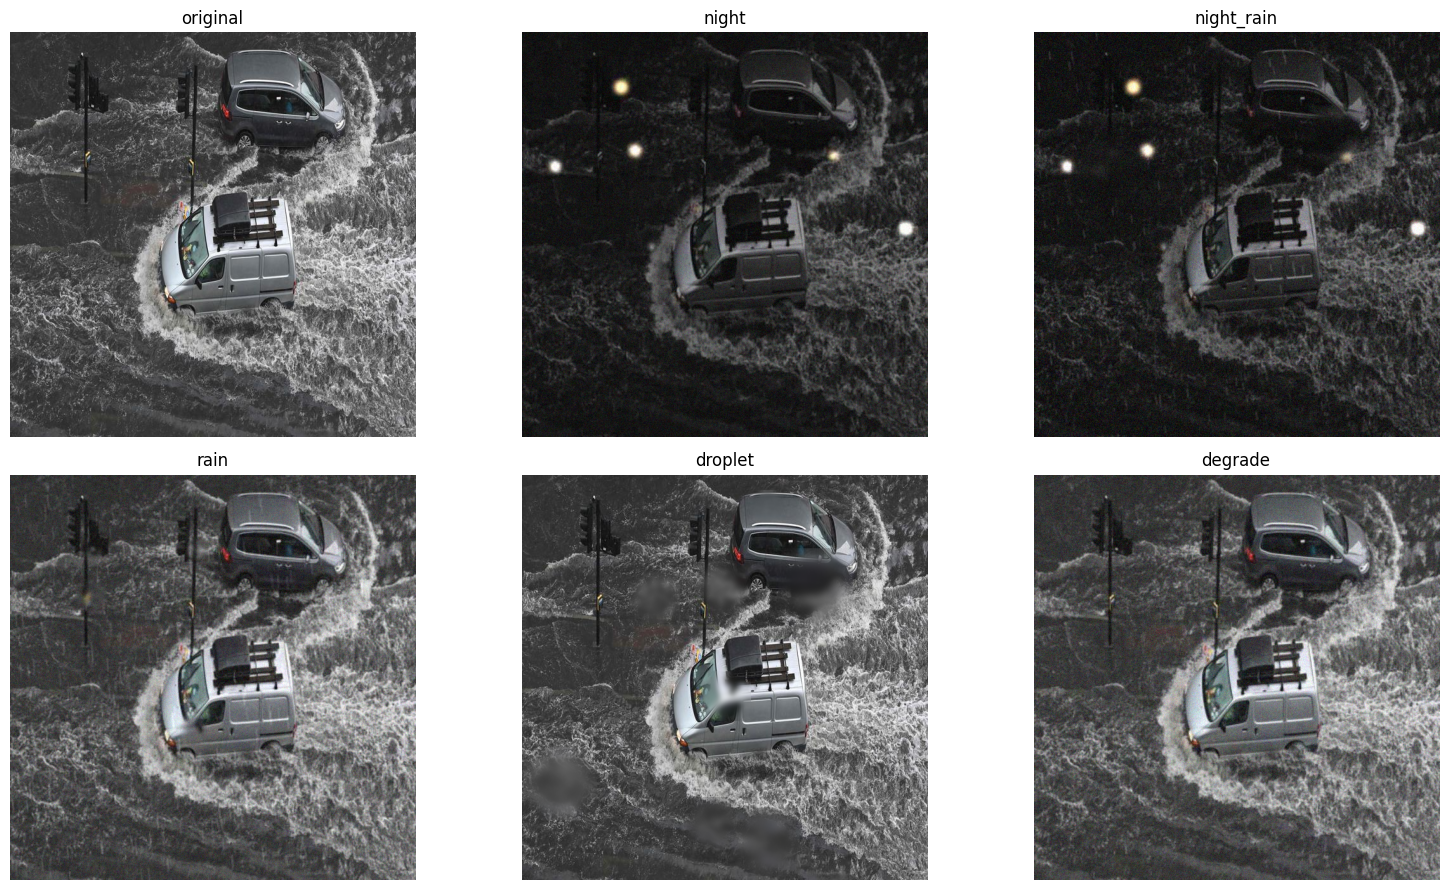

In [6]:
# ── 수정 지점 ───────────────────────────────────────────────
DST_ROOT = Path(r"C:\Project\PythonProject\PyTorch001\datasets\water_seg")
# ───────────────────────────────────────────────────────────

def load_mask(label_path, h, w):
    m = np.zeros((h, w), np.uint8)
    if not label_path.exists():
        return m
    for line in label_path.read_text(encoding="utf-8").splitlines():
        v = line.split()
        if len(v) < 7:
            continue
        pts = np.array(list(map(float, v[1:])), np.float32).reshape(-1, 2)
        pts[:, 0] *= w; pts[:, 1] *= h
        cv2.fillPoly(m, [pts.astype(np.int32)], 1)
    return m


files = sorted((DST_ROOT / "images" / "train").glob("*.jpg"))
print("train 이미지:", len(files))

f = files[0]
bgr = cv2.imread(str(f))
h, w = bgr.shape[:2]
mask = load_mask(DST_ROOT / "labels" / "train" / (f.stem + ".txt"), h, w)
print(f"{f.name} | {w}x{h} | 물 픽셀 비율 {mask.mean():.3f}")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, name in zip(axes.ravel(), ["original"] + PRESETS):
    img = bgr if name == "original" else augment(bgr, mask, preset=name, seed=7)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(name); ax.axis("off")
plt.tight_layout(); plt.show()

확인할 것

- **야간 프리셋에서 반사 줄무늬가 물 영역 안에만 있는가** — 도로 위로 새어 나오면 마스크가 잘못된 것
- 너무 어둡지 않은가 — 물 경계가 아예 안 보이면 학습에 해롭습니다
- 빗줄기가 과하지 않은가 — 화면을 덮으면 물 자체가 가려집니다

`strength` 인자로 강도를 조절할 수 있습니다. 처음에는 약하게 시작하세요.

## 3. 증강 데이터셋 생성

In [7]:
# ── 증강 설정 ───────────────────────────────────────────────
AUG_ROOT = Path(r"C:\Project\PythonProject\PyTorch001\datasets\water_seg_aug")
AUG_PLAN = {          # 프리셋별로 train의 몇 %를 증강할지
    "night":      0.5,
    "night_rain": 0.3,
    "rain":       0.3,
    "droplet":    0.2,
    "degrade":    0.4,
}
SEED = 42
# ───────────────────────────────────────────────────────────

def build_augmented(src_root=DST_ROOT, dst_root=AUG_ROOT, plan=AUG_PLAN, seed=SEED):
    rng = random.Random(seed)

    for split in ["train", "valid", "test"]:
        (dst_root / "images" / split).mkdir(parents=True, exist_ok=True)
        (dst_root / "labels" / split).mkdir(parents=True, exist_ok=True)

    # 1) 원본 전량 복사 (증강본은 '대체'가 아니라 '추가')
    n_copy = 0
    for split in ["train", "valid", "test"]:
        for img in (src_root / "images" / split).glob("*.jpg"):
            lbl = src_root / "labels" / split / (img.stem + ".txt")
            di = dst_root / "images" / split / img.name
            dl = dst_root / "labels" / split / lbl.name
            if not di.exists():
                try:
                    os.link(img, di)
                except Exception:
                    shutil.copy2(img, di)
            if lbl.exists() and not dl.exists():
                shutil.copy2(lbl, dl)
            n_copy += 1
    print(f"원본 복사 {n_copy}장")

    # 2) train만 증강 (valid/test는 절대 증강하지 않음)
    train_imgs = sorted((src_root / "images" / "train").glob("*.jpg"))
    made = 0
    for preset, ratio in plan.items():
        picks = rng.sample(train_imgs, int(len(train_imgs) * ratio))
        for i, f in enumerate(picks):
            bgr = cv2.imread(str(f))
            if bgr is None:
                continue
            h, w = bgr.shape[:2]
            lbl = src_root / "labels" / "train" / (f.stem + ".txt")
            mask = load_mask(lbl, h, w)

            out = augment(bgr, mask, preset=preset, seed=rng.randrange(10**8))
            name = f"{f.stem}__{preset}.jpg"
            cv2.imwrite(str(dst_root / "images" / "train" / name), out,
                        [int(cv2.IMWRITE_JPEG_QUALITY), 92])
            # 기하 변환이 없으므로 라벨 그대로 복사
            if lbl.exists():
                shutil.copy2(lbl, dst_root / "labels" / "train" / f"{f.stem}__{preset}.txt")
            else:
                (dst_root / "labels" / "train" / f"{f.stem}__{preset}.txt").write_text("", encoding="utf-8")
            made += 1
        print(f"  {preset:12s} +{len(picks)}장")

    print(f"\n증강 생성 {made}장")
    for split in ["train", "valid", "test"]:
        n = len(list((dst_root / "images" / split).glob("*.jpg")))
        print(f"  {split:6s}: {n}장")
    return dst_root


build_augmented()

원본 복사 567장
  night        +210장
  night_rain   +126장
  rain         +126장
  droplet      +84장
  degrade      +168장

증강 생성 714장
  train : 1135장
  valid : 92장
  test  : 54장


WindowsPath('C:/Project/PythonProject/PyTorch001/datasets/water_seg_aug')

**`valid`와 `test`는 절대 증강하지 않았습니다.**
증강 데이터로 학습하고 증강 데이터로 평가하면 순환 검증이 되어, 실제 개선이 없어도 점수가 오릅니다.

In [8]:
import yaml

data = {
    "path": str(AUG_ROOT),
    "train": "images/train",
    "val": "images/valid",
    "test": "images/test",
    "names": {0: "water"},
}
YAML_AUG = AUG_ROOT / "data.yaml"
YAML_AUG.write_text(yaml.safe_dump(data, allow_unicode=True, sort_keys=False), encoding="utf-8")
print(YAML_AUG.read_text(encoding="utf-8"))

path: C:\Project\PythonProject\PyTorch001\datasets\water_seg_aug
train: images/train
val: images/valid
test: images/test
names:
  0: water



## 4. 네거티브 샘플 추가 — 오탐 억제

물 인식의 최대 난적은 야간 어둠이 아니라 **젖은 아스팔트**입니다.
비 온 뒤 노면 반사는 실제 침수와 거의 구분되지 않습니다.

이건 증강으로 못 고칩니다. **"젖었지만 침수는 아닌" 프레임을 빈 라벨로 직접 넣어야** 합니다.
침수 상황이 아니어도 되므로 수집이 쉽습니다 — AI Hub 165 야간 프레임이나
공개 CCTV 캡처를 그대로 쓰면 됩니다.

In [9]:
NEG_DIR = Path(r"C:\Users\Win11Pro\Downloads\negative_frames")   # 물 없는 야간/우천 프레임
NEG_LIMIT = 150

def add_negatives(neg_dir=NEG_DIR, dst_root=AUG_ROOT, limit=NEG_LIMIT, split="train"):
    neg_dir = Path(neg_dir)
    if not neg_dir.exists():
        print(f"[건너뜀] 폴더 없음: {neg_dir}")
        print("  -> AI Hub 165 야간 프레임이나 공개 CCTV 캡처를 이 경로에 모으세요")
        return 0

    files = sorted([f for f in neg_dir.iterdir()
                    if f.suffix.lower() in (".jpg", ".jpeg", ".png")])[:limit]
    n = 0
    for f in files:
        img = cv2.imread(str(f))
        if img is None:
            continue
        name = f"neg_{f.stem}.jpg"
        cv2.imwrite(str(dst_root / "images" / split / name), img,
                    [int(cv2.IMWRITE_JPEG_QUALITY), 92])
        # 빈 라벨 = 이 이미지에 물이 없다는 명시적 학습 신호
        (dst_root / "labels" / split / f"neg_{f.stem}.txt").write_text("", encoding="utf-8")
        n += 1
    print(f"네거티브 {n}장 추가")
    return n


add_negatives()

[건너뜀] 폴더 없음: C:\Users\Win11Pro\Downloads\negative_frames
  -> AI Hub 165 야간 프레임이나 공개 CCTV 캡처를 이 경로에 모으세요


0

네거티브는 **train 전체의 20~25%를 넘지 않게** 하세요.
과하면 모델이 "웬만하면 물 아님"으로 기울어 Recall이 떨어집니다.

## 5. 재학습

In [10]:
import torch
from ultralytics import YOLO

model = YOLO("yolo26n-seg.pt")   # 증강 효과 측정이 목적이므로 v3와 동일 조건 유지

results = model.train(
    data=str(YAML_AUG),
    epochs=300,
    patience=40,
    imgsz=640,
    batch=8,
    device=0 if torch.cuda.is_available() else "cpu",
    workers=2,
    project=r"C:\Project\PythonProject\PyTorch001\runs_water_aug",
    name="water_seg_aug",
    exist_ok=True,
    cache="ram",
    optimizer="auto", cos_lr=True, amp=True,

    # 증강을 오프라인에서 이미 걸었으므로 학습 내 색상 증강은 약하게
    hsv_h=0.010, hsv_s=0.4, hsv_v=0.3,
    degrees=0.0, translate=0.1, scale=0.4,
    fliplr=0.5, flipud=0.0,
    mosaic=1.0, close_mosaic=15, copy_paste=0.3,
    val=True, plots=True, seed=42,
)

SAVE_DIR = Path(results.save_dir)
BEST_PT = SAVE_DIR / "weights" / "best.pt"
print("best.pt:", BEST_PT)

New https://pypi.org/project/ultralytics/8.4.115 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.86  Python-3.11.9 torch-2.12.0.dev20260408+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Project\PythonProject\PyTorch001\datasets\water_seg_aug\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.4, hsv_v=0.3, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train

학습 내 `hsv_v`를 낮춘 이유는, 오프라인에서 이미 밝기·색온도를 크게 흔들었기 때문입니다.
양쪽에서 동시에 강하게 걸면 원본 분포에서 너무 멀어집니다.

## 6. 평가 — 조건별로 나눠서 봐야 의미가 있습니다

전체 평균 하나만 보면 **주간 성능이 떨어지는 걸 놓칩니다.**
증강을 과하게 하면 야간이 조금 오르고 주간이 크게 떨어지는 경우가 흔합니다.

In [11]:
def load_gt(label_path, h, w):
    return load_mask(label_path, h, w)


def pixel_eval(weights, data_root, split="test", conf=0.25, name=""):
    m = YOLO(str(weights))
    dev = 0 if torch.cuda.is_available() else "cpu"
    img_dir = Path(data_root) / "images" / split
    lbl_dir = Path(data_root) / "labels" / split

    inter = union = gt_t = pr_t = 0
    for f in sorted(img_dir.glob("*.jpg")):
        bgr = cv2.imread(str(f))
        if bgr is None:
            continue
        h, w = bgr.shape[:2]
        gt = load_gt(lbl_dir / (f.stem + ".txt"), h, w)
        r = m.predict(source=bgr, conf=conf, imgsz=640, device=dev, verbose=False)[0]
        pr = np.zeros((h, w), np.uint8)
        if r.masks is not None:
            for mm in r.masks.data.cpu().numpy():
                mm = cv2.resize(mm.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)
                pr |= (mm > 0.5).astype(np.uint8)
        inter += int(np.logical_and(gt, pr).sum())
        union += int(np.logical_or(gt, pr).sum())
        gt_t += int(gt.sum()); pr_t += int(pr.sum())

    out = {"name": name, "iou": inter / max(union, 1),
           "precision": inter / max(pr_t, 1), "recall": inter / max(gt_t, 1)}
    print(f"{name:22s} IoU {out['iou']:.4f} | P {out['precision']:.4f} | R {out['recall']:.4f}")
    return out


V3_PT = r"C:\Project\PythonProject\PyTorch001\runs_water_v3\exported\water_seg_v3_best.pt"

print("=== 주간 test (기존 데이터) — 여기가 떨어지면 증강 실패 ===")
rows = []
for pt, nm in [(V3_PT, "v3 (증강 전)"), (BEST_PT, "aug (증강 후)")]:
    if Path(pt).exists():
        rows.append(pixel_eval(pt, DST_ROOT, "test", name=nm))

=== 주간 test (기존 데이터) — 여기가 떨어지면 증강 실패 ===
v3 (증강 전)              IoU 0.7126 | P 0.9257 | R 0.7558
aug (증강 후)             IoU 0.6843 | P 0.9293 | R 0.7219


### 야간·우천 실제 평가셋

합성으로 학습했더라도 **평가는 실제 프레임으로** 해야 합니다.
공개 CCTV에서 야간·우천 프레임을 **30~50장만** 캡처해 직접 라벨링하세요.
이 정도는 하루면 충분하고, 없으면 이후 모든 실험이 의미를 잃습니다.

```
datasets/real_night_test/
  images/test/*.jpg
  labels/test/*.txt
```

In [12]:
REAL_TEST = Path(r"C:\Project\PythonProject\PyTorch001\datasets\real_night_test")

if (REAL_TEST / "images" / "test").exists():
    print("=== 야간·우천 실제 test ===")
    for pt, nm in [(V3_PT, "v3 (증강 전)"), (BEST_PT, "aug (증강 후)")]:
        if Path(pt).exists():
            pixel_eval(pt, REAL_TEST, "test", name=nm)
else:
    print("실제 야간 평가셋이 아직 없습니다.")
    print("공개 CCTV 야간/우천 프레임 30~50장을 캡처해 라벨링하세요.")
    print("이것 없이는 증강 효과를 검증할 방법이 없습니다.")

실제 야간 평가셋이 아직 없습니다.
공개 CCTV 야간/우천 프레임 30~50장을 캡처해 라벨링하세요.
이것 없이는 증강 효과를 검증할 방법이 없습니다.


## 7. 판정 기준

| 결과 | 해석 | 조치 |
|---|---|---|
| 주간 유지 + 야간 상승 | 성공 | 증강 비율을 조금 더 올려 재실험 |
| 주간 하락 + 야간 상승 | 과증강 | `AUG_PLAN` 비율을 절반으로 |
| 주간 유지 + 야간 변화 없음 | 합성이 실제와 다름 | SDXL 야간 인페인팅으로 전환 |
| 양쪽 다 하락 | 증강이 라벨과 불일치 | 2번 셀 시각 확인부터 재점검 |

`가장 흔한 실패는 세 번째`입니다. 그 경우 픽셀 필터 방식의 한계이므로,
**AI Hub 165의 야간 프레임에 SDXL 인페인팅으로 물을 직접 생성**하는 쪽이 답입니다.
인페인팅 마스크가 곧 GT라 라벨링 비용도 없습니다.

프롬프트 예시
```
flooded urban road at night, streetlight reflections streaking on the water
surface, wet reflective asphalt, low-light CCTV footage, muddy brown water
```